# 第14课 · 找到矩阵偏爱的方向——特征值（eigenvalue）与 SVD，打开低秩世界的钥匙

**学习目标（两条线）**
1. **线 ①**：验证特征向量方程 `Av = λv`（方向不变的轴）
2. **线 ②**：用 SVD 做低秩近似 `low_rank_approx(A, k)`（只留前 k 个奇异值）
3. PCA：同一把钥匙的「数据说法」——找变化最大的方向（与 ① 相连，不另起炉灶）

**为什么对 Aurora 重要**：SVD 是音频去噪（截断低秩 STFT）、降维可视化，以及以后低秩适配（如 LoRA，L84）的共同数学基础——本课先会「扔不重要的方向」。

← **上一课**　[L13 · 特殊矩阵](L13_special_matrices.ipynb)

> 上节课学习了 **特殊矩阵**：正交矩阵保长度、对称矩阵 = 镜子、正定的能量判据。  
> 本课将探讨 **特征值与 SVD**。

## 本课剧情：矩阵有"偏爱的方向"

你有没有注意到，有些人在被压力推一把后，会沿着自己固有的方向走——不会被"推歪"？

矩阵也有这样的"偏爱方向"：**特征向量（eigenvector）**。

对于矩阵 A，特征向量 v 满足：`Av = λv`  
意思是：A 作用于 v 之后，v 的**方向不变**，只有长度被拉伸了 λ 倍。λ 就是特征值。

为什么重要？PCA 找的是"数据变化最大的方向"——这就是协方差矩阵的最大特征向量。SVD 把任意矩阵分解成三个部分：`A = U·S·Vᵀ`，每个奇异值（singular value，σ） σᵢ 衡量该方向的"重要性"。

**本课两个任务**（对应上面两条线）：
1. 验证 Av = λv（特征向量方向不变）
2. 实现 `low_rank_approx(A, k)`（只保留前 k 个奇异值——以后低秩微调会再用这把刀）

## 🤔 为什么工程师要发明它？(Why did engineers invent this?)

很多人上完课还觉得"SVD 没真懂"，问题几乎都不在数学，而在**没先搞清它是干嘛用的**。先记住用途，推导以后自然通。

- **不用它会怎样？** 一张 1000×1000 的图片是一百万个数字；一张推荐系统的"用户 × 电影"评分表可能上亿格。原样存储、传输、计算都太贵，而且里面大量信息是重复、冗余的。工程师需要一种"抓主干、扔细节"的通用办法。
- **它解决了什么真实问题？** SVD 把**任意**矩阵按重要性排好序，拆成一叠方向：`A = σ₁u₁v₁ᵀ + σ₂u₂v₂ᵀ + …`。真实数据里，前几个奇异值 σ 往往就装下了绝大部分信息。只留前 k 个，就得到一个又小又几乎一样的"低秩（low-rank）"版本——**压缩、去噪、降维，本质都是这一招**。
- **后面哪里还会再用到？** L17 用特征分解看系统稳定性、**L84 的 LoRA** 用两个低秩因子微调大模型；Month 4 推荐系统、Month 5 的 embedding 降维可视化，全是同一把钥匙。

> 一句话记牢：**SVD 不是为了"算"，是为了"扔"——扔掉不重要的方向。** 下面的代码只是在帮你把这句话看见。


## 插播：“秩”到底是什么？

后面我们会反复说“低秩”“秩-k 近似”，但还没有把“秩”这个词本身讲清楚。这里先按下暂停键，把地基打好，免得后面越滚越糊涂。

打个比方：假如你有一份 100 人的通讯录，但这 100 人全部来自同一个家庭群——很多行其实是“重复”或者“能由别的行推算出来”的（比如“爸爸电话”和“妈妈电话”对应的都是同一个家庭地址）。真正“独立”、没法由其他行拼凑出来的信息，其实远没有 100 条。

矩阵的**秩（rank）**，说的就是这件事：**一个矩阵里，最多能找出几个互相“线性无关”的方向**（谁也不是别人的倍数或组合）。具体例子：

- 矩阵 `[[1, 2], [2, 4]]`：第二行 = 2 × 第一行，两行其实只提供了“一个独立方向”的信息 —— **秩 = 1**。
- 矩阵 `[[1, 0], [0, 1]]`（单位矩阵）：两行互不相关，各自指向一个独立方向 —— **秩 = 2（满秩）**。

今天先记住一句话：**秩 = 矩阵里独立方向的数量**。等学到 SVD 后，我们会看到一个更好用的等价说法——**矩阵的秩 = 它的非零奇异值的个数**——那时“秩-k 近似”这个词就完全落地了。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np

# 秩 = 1 的例子：第二行是第一行的整数倍，没有提供新方向
A_rank1 = np.array([[1., 2.], [2., 4.]])
print('A_rank1 的秩 =', np.linalg.matrix_rank(A_rank1))

# 秩 = 2（满秩）的例子：两行互相独立
A_full = np.array([[1., 0.], [0., 1.]])
print('A_full  的秩 =', np.linalg.matrix_rank(A_full))


A_rank1 的秩 = 1
A_full  的秩 = 2


## 1. 特征向量：Av = λv（方向不变的轴）

举个直觉例子：对角矩阵 A = [[2, 0], [0, 3]]  
- 轴 e₁ = [1, 0]：A @ [1, 0] = [2, 0] = **2** × [1, 0]  → 特征值 λ₁ = 2
- 轴 e₂ = [0, 1]：A @ [0, 1] = [0, 3] = **3** × [0, 1]  → 特征值 λ₂ = 3

对角矩阵的特征向量就是坐标轴。**非对角矩阵的特征向量是它自己偏爱的方向，通常不再和原始坐标轴重合。**

`np.linalg.eig(A)` 返回 `(eigenvalues, eigenvectors)`:
- `vals[i]` 是第 i 个特征值
- `vecs[:, i]` 是第 i 个特征向量（列向量）

验证：`A @ vecs[:, i] ≈ vals[i] * vecs[:, i]`（两边都是同一方向的向量）

（这句话初读容易绕：更准确的说法是——非对角矩阵一般不再是标准的 x 轴、y 轴，而是一组新的、经过旋转后的正交方向。下面马上用一个具体例子把这句话钉死，同时把 `Av = λv` 这个等式到底怎么来的也讲透。）

## 1.0 从"方向不变"到 `Av = λv`——这个等式是怎么来的？

上面说"特征向量是方向不变的轴"，这是一句大白话；`Av = λv` 是一句数学话。这两句话到底是怎么对上号的？我们一步步来。

**第一步，回忆高中知识**：给一个向量 v 乘一个数字 λ（比如 v=[1,1]，λ=3），得到 λv=[3,3]。这个新向量和原来的 v 是什么关系？——**在同一条直线上**：
- 如果 λ>0（比如 3），λv 和 v 指向同一个方向，只是变长了；
- 如果 λ<0（比如 -3），λv 和 v 指向相反方向（也可以说方向"转了 180°"），长度变成 |λ| 倍。

不管哪种情况，v 和 λv 都**共线**——没有偏离原来那条直线。这正是我们想表达的"方向不变"（严格地说，是"方向不变或恰好反向"）。

**第二步，倒过来看**：如果我们发现 A 作用在某个向量 v 上，结果 `Av` 恰好等于 v 的某个倍数——也就是存在一个数 λ，使 `Av = λv`——那就说明 `Av` 一定和 v 共线，这正是"方向不变"的代数写法。所以这里**不写** `Av ∝ v`（正比例符号说不清具体倍数是多少），而是把倍数 λ 显式写出来，因为 λ 本身也是我们关心的量——它告诉我们"到底拉伸/压缩了多少"。

**第三步，特征方程从哪来**：把 `Av = λv` 两边都移到左边：

```
Av - λv = 0
Av - λ(Iv) = 0        # 用单位矩阵 I 把 λv 写成 λIv，这样两边都是"矩阵 × 向量"
(A - λI)v = 0
```

这个式子说的是："矩阵 `(A - λI)` 作用在 v 上得到零向量"。特征向量按定义不能是零向量（零向量没有"方向"可言），所以 v 是非零的——这意味着 `(A - λI)` 这个矩阵把一个非零向量"压扁"成了 0，也就是说它存在非平凡的零空间，因而必须是不可逆的（行列式为 0）。于是我们可以先解 `det(A - λI) = 0` 这个方程把所有可能的 λ 找出来，再回代求出对应的 v——这就是"特征方程"名字的来源。

### 非对角矩阵的特征向量长什么样？——一个真正非对角的例子

之前只看了对角矩阵，特征向量正好是 x 轴、y 轴，太"巧"了，容易让人误以为特征向量永远是坐标轴。现在换一个真正的非对角矩阵 `A = [[3, 2], [2, 3]]`（对称矩阵），看看它的特征向量到底指向哪里，并画图直接看一眼"方向不变"是什么样子。

特征值: [5.+0.j 1.+0.j]
特征向量(按列):
 [[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]
注意：这两个方向不再是 [1,0]、[0,1]，而是被"转过"了 45°/135° 的方向。
验证 A @ v1 与 λ1 * v1 是否一致: True


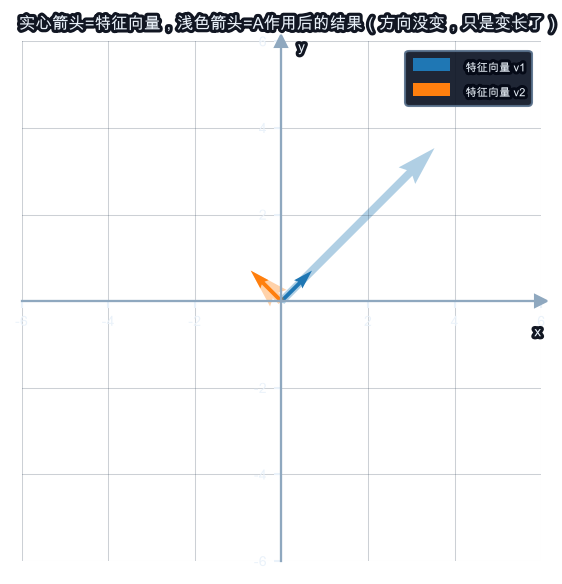

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 一个非对角矩阵：对称矩阵 [[3,2],[2,3]]
A_sym = np.array([[3.0, 2.0], [2.0, 3.0]])
vals_sym, vecs_sym = np.linalg.eig(A_sym)
print('特征值:', vals_sym)
print('特征向量(按列):\n', vecs_sym)
print('注意：这两个方向不再是 [1,0]、[0,1]，而是被"转过"了 45°/135° 的方向。')

# 画出特征向量方向，以及矩阵作用在它们身上之后的结果
plt.figure(figsize=(4.5, 4.5))
origin = np.zeros(2)
colors = ['tab:blue', 'tab:orange']
for i in range(2):
    v = vecs_sym[:, i]
    Av = A_sym @ v
    plt.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1, color=colors[i], label=f'特征向量 v{i+1}')
    plt.quiver(*origin, *Av, angles='xy', scale_units='xy', scale=1, color=colors[i], alpha=0.35, width=0.015)

plt.xlim(-6, 6); plt.ylim(-6, 6)
plt.axhline(0, color='gray', lw=.5); plt.axvline(0, color='gray', lw=.5)
plt.gca().set_aspect('equal'); plt.grid(True, alpha=.25); plt.legend()
plt.title('实心箭头=特征向量，浅色箭头=A作用后的结果（方向没变，只是变长了）')
plt.show()

print('验证 A @ v1 与 λ1 * v1 是否一致:', np.allclose(A_sym @ vecs_sym[:, 0], vals_sym[0] * vecs_sym[:, 0]))


### 特征值一定是实数吗？——为什么连对角矩阵也带着 `+0.j`

你可能已经注意到（哪怕是对角矩阵这么"老实"的矩阵），`np.linalg.eig` 的输出也长成 `2.+0.j` 这样带"虚部"的样子。这里把背后的规律说清楚：

- `np.linalg.eig` 是一个**通用**函数：不管你喂给它的矩阵是不是对称的，它统一按"结果可能是复数"的规格来返回——数组的数据类型（dtype）固定是 `complex128`，哪怕算出来的虚部全是 0，也会带着 `+0.j` 的标签。这只是数据类型上的保守选择，不代表你的矩阵有问题。
- 但"虚部是不是恰好为 0"这件事，确实和矩阵的性质有关：如果矩阵是**实对称矩阵**（比如 `[[3,2],[2,3]]`，转置后和自己相等）或对角矩阵，可以证明它的特征值在数学上必然是实数，所以算出来的虚部会恰好是 0（只是外壳仍是复数类型）。
- 对于**一般的非对称实矩阵**，特征值可能真的带有非零虚部。经典例子是"旋转矩阵" `[[0,-1],[1,0]]`——它把平面上任何向量都转 90°，根本找不到一个"方向不变"的实向量，于是特征值只能是货真价实的复数（虚数单位 `i` 正是数学家为了让"纯旋转"也能有特征值而引入的记账方式）。
- 如果明确知道矩阵是对称的，想要一个直接返回纯实数的版本，可以用 `np.linalg.eigh`（h 代表 Hermitian/对称），它专门针对对称矩阵优化，输出就是普通的 `float64`。

下面对比三种矩阵：对称矩阵（虚部为 0，但外壳仍是复数）、旋转矩阵（虚部非零）、以及用 `eigh` 得到的纯实数结果。

In [4]:
import numpy as np

A_rot = np.array([[0., -1.], [1., 0.]])  # 90 度旋转矩阵
vals_rot, _ = np.linalg.eig(A_rot)
print('旋转矩阵 eig 的特征值:', vals_rot, ' <- 虚部非零，货真价实的复数')

A_sym2 = np.array([[3.0, 2.0], [2.0, 3.0]])
vals_sym2, _ = np.linalg.eig(A_sym2)
print('对称矩阵 eig  的特征值:', vals_sym2, ' <- dtype仍是complex128，但虚部恰好为0')

vals_sym2_h = np.linalg.eigvalsh(A_sym2)
print('对称矩阵 eigh 的特征值:', vals_sym2_h, ' <- dtype是float64，专为对称矩阵优化')


旋转矩阵 eig 的特征值: [0.+1.j 0.-1.j]  <- 虚部非零，货真价实的复数
对称矩阵 eig  的特征值: [5.+0.j 1.+0.j]  <- dtype仍是complex128，但虚部恰好为0
对称矩阵 eigh 的特征值: [1. 5.]  <- dtype是float64，专为对称矩阵优化


## 符号入口：本节关键 shape

本节的关键 shape 变化：输入矩阵 A 是 `(m, n)`，特征向量 v 是 `(n,)`，奇异值向量 S 是 `(min(m,n),)`。

**Full SVD**（`full_matrices=True`，默认）：U 是 `(m, m)`，Vt 是 `(n, n)`。

**Thin SVD**（`full_matrices=False`）：U 是 `(m, k)`，Vt 是 `(k, n)`，其中 `k = min(m, n)`——只保留非零奇异值对应的列/行，结果更紧凑，低秩近似时常用。cell-8 使用的就是 thin SVD，所以 A=(2,3) 时 Vt.shape=(2,3) 而非 (3,3)。

特征值问题 `Av = λv` 要求 A 是方阵；SVD 对任意矩阵都成立。

### 追问：Thin SVD 到底省在哪？为什么 Full 和 Thin 做低秩近似结果一样？

一个很实际的问题：如果 Full SVD 也能做出正确的秩-k 近似（反正最后都是只取前 k 列/行），那为什么还要专门有个 Thin SVD？

答案是：**两种 SVD 数学上完全等价，算出来的低秩近似结果一模一样**，区别只在于"要不要先计算、存储那些反正会被丢掉的部分"。Full SVD 会老老实实算出完整的 `U (m×m)` 和 `Vt (n×n)`，哪怕你最后只打算用前 k 列/行；Thin SVD 直接只算 `min(m,n)` 维那一部分，跳过没用的计算。矩阵越大、m 和 n 差得越远，这个差距越明显。`low_rank_approx` 两种都能用（下面练习里用的是 Full SVD 再切片，同样正确），只是处理超大矩阵时通常会选 Thin，省时间也省内存。

下面用一个 4×3 的矩阵实测：两者做秩-2 近似，结果应完全一致，但两种方式各自要存的数字个数不同。

In [5]:
import numpy as np

A_cmp = np.array([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.], [10., 11., 12.]])  # 4x3
m, n = A_cmp.shape

U_full, S_full, Vt_full = np.linalg.svd(A_cmp, full_matrices=True)
U_thin, S_thin, Vt_thin = np.linalg.svd(A_cmp, full_matrices=False)
print(f'Full SVD:  U{U_full.shape}  S{S_full.shape}  Vt{Vt_full.shape}')
print(f'Thin SVD:  U{U_thin.shape}  S{S_thin.shape}  Vt{Vt_thin.shape}')

k = 2
A_k_full = U_full[:, :k] @ np.diag(S_full[:k]) @ Vt_full[:k, :]
A_k_thin = U_thin[:, :k] @ np.diag(S_thin[:k]) @ Vt_thin[:k, :]
print('两种方式的秩-2近似是否一致:', np.allclose(A_k_full, A_k_thin))

# 存储量对比（完整分解阶段，还没切出前 k 列/行之前）
full_numbers = U_full.size + S_full.size + Vt_full.size
thin_numbers = U_thin.size + S_thin.size + Vt_thin.size
print(f'Full SVD 需要存储的数字个数: {full_numbers}')
print(f'Thin SVD 需要存储的数字个数: {thin_numbers}')


Full SVD:  U(4, 4)  S(3,)  Vt(3, 3)
Thin SVD:  U(4, 3)  S(3,)  Vt(3, 3)
两种方式的秩-2近似是否一致: True
Full SVD 需要存储的数字个数: 28
Thin SVD 需要存储的数字个数: 24


## 1.1 特征向量和普通向量的差别

同一个矩阵作用到不同方向上，结果可能会转弯，也可能只变长。特征向量就是“不转弯”的方向。


In [6]:
import numpy as np

A = np.array([[2.0, 0.0], [0.0, 3.0]])
eigen_v = np.array([1.0, 0.0])
ordinary_v = np.array([1.0, 1.0])

print('A @ eigen_v   =', A @ eigen_v, ' 方向不变')
print('A @ ordinary_v=', A @ ordinary_v, ' 方向改变')


A @ eigen_v   = [2. 0.]  方向不变
A @ ordinary_v= [2. 3.]  方向改变


In [7]:
import numpy as np
A = np.array([[2.0,0.0],[0.0,3.0]])
vals, vecs = np.linalg.eig(A)
print('特征值 λ:', vals)          # [2. 3.]
print('特征向量(按列):\n', vecs)  # x轴、y轴

特征值 λ: [2.+0.j 3.+0.j]
特征向量(按列):
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


## 动手观察

对角矩阵的特征向量正好是坐标轴方向：检查 `A @ vecs[:, i]` 与 `vals[i] * vecs[:, i]` 的数值差是否小于 `1e-10`，再换一个非特征方向的向量验证方向确实偏转。

### 📐 小例子：为什么"低秩 = 压缩"（手数一遍存储量）

把一张 8×8 的灰度小图看成一个 8×8 矩阵，就是 **64 个数字**。对它做 SVD 后，如果奇异值衰减很快（真实图片几乎都这样），只保留最大的 **k=2** 个奇异值就够看个大概。这时需要存的只有：

| 要存的东西 | 数量 |
|---|---|
| 2 列 `u`（每列 8 个数） | 2 × 8 = 16 |
| 2 个奇异值 σ | 2 |
| 2 行 `vᵀ`（每行 8 个数） | 2 × 8 = 16 |
| **合计** | **34** |

64 → 34，省了将近一半。矩阵越大越夸张：一张 1000×1000 的图（一百万个数）只留前 10 个奇异值，需要 `10 × (1000 + 1000 + 1) ≈ 2 万`个数——**压到原来的 2%**，肉眼几乎看不出差别。这就是 JPEG、模型压缩背后同一套直觉。下面的 cell 就用一个真矩阵，把"k 越大、误差越小"这条曲线跑给你看。


In [8]:
import numpy as np

# SVD 分解：A = U @ diag(σ) @ V^T
A = np.array([[3., 2., 1.],[2., 3., 1.]], float)
U, s, Vt = np.linalg.svd(A, full_matrices=False)
print(f'A ({A.shape}):'); print(A)
print(f'奇异值 σ = {np.round(s, 4)}')
print(f'U shape={U.shape}, Vt shape={Vt.shape}')
A_rec = U @ np.diag(s) @ Vt
print(f'重建误差 = {np.max(np.abs(A - A_rec)):.2e}  （应接近 0）')


A ((2, 3)):
[[3. 2. 1.]
 [2. 3. 1.]]
奇异值 σ = [5.1962 1.    ]
U shape=(2, 2), Vt shape=(2, 3)
重建误差 = 1.33e-15  （应接近 0）


### 插播：马上要出现的"Frobenius 误差"，这把尺子是什么？

下面很快会用"Frobenius 重建误差"衡量"近似矩阵和原矩阵差多少"，这里先把这把尺子讲清楚，免得看到 `norm(..., 'fro')` 一头雾水。

对一个普通向量，我们习惯用"长度"（即 L2 范数）衡量大小：把每个分量平方、加起来、再开根号。**Frobenius 范数**就是把这套办法直接搬到矩阵上——把矩阵摊平看成一长串数字，同样是"每个数字平方、全部加起来、再开根号"：

`||A||_F = sqrt( Σᵢ Σⱼ (A[i,j])² )`

举个例子：矩阵 `[[3, 4]]` 的 Frobenius 范数 = `sqrt(3² + 4²) = sqrt(25) = 5`——和向量 `[3,4]` 的长度算法一模一样，只是把"矩阵"当成了"摊平的长向量"。

而"重建误差" `||A - A_k||_F`，就是把 `(A - A_k)` 这个"差值矩阵"的每个元素平方、加总、再开根号——衡量的是"原矩阵和近似矩阵，逐个格子的差异总共有多大"。它把矩阵的整体偏差归纳成一个单一数字，方便比较不同 k 下的近似好坏。

In [9]:
import numpy as np

toy = np.array([[3., 4.]])
print('手算 sqrt(3^2+4^2)      =', np.sqrt(3**2 + 4**2))
print('np.linalg.norm(toy, "fro") =', np.linalg.norm(toy, 'fro'))

diff = np.array([[1., 2.], [2., 1.]])
manual = np.sqrt(np.sum(diff ** 2))
print('手算 Frobenius 范数      =', manual)
print('np.linalg.norm(diff, "fro") =', np.linalg.norm(diff, 'fro'))


手算 sqrt(3^2+4^2)      = 5.0
np.linalg.norm(toy, "fro") = 5.0
手算 Frobenius 范数      = 3.1622776601683795
np.linalg.norm(diff, "fro") = 3.1622776601683795


## 代码实验：秩-k 近似预览——只保留前 k 个奇异值

下面的参考演示对 3×3 矩阵做 SVD，依次保留 1、2、3 个奇异值并计算 Frobenius 重建误差：k 越大误差越小，秩-1 已捕获最主要的方向。这正是稍后练习 `low_rank_approx` 要实现的操作，完成 TODO 后可回来对照。

In [10]:
# 警告：参考演示（请先完成 cell-18 的 low_rank_approx TODO，再回来对照）
import numpy as np

# SVD 秩-k 近似：只保留前 k 个奇异值（变量名加 _ref 区分练习中的变量）
A_ref = np.array([[1,2,3],[4,5,6],[7,8,9]], float)
U_ref, s_ref, Vt_ref = np.linalg.svd(A_ref)
for k in [1, 2, 3]:
    Ak_ref = U_ref[:, :k] @ np.diag(s_ref[:k]) @ Vt_ref[:k, :]
    err = np.linalg.norm(A_ref - Ak_ref, 'fro')
    print(f'秩-{k} 近似  Frobenius 误差={err:.4f}')
print('-> 秩-1 捕获最主要的方向，误差由 sigma_2 决定。')

秩-1 近似  Frobenius 误差=1.0684
秩-2 近似  Frobenius 误差=0.0000
秩-3 近似  Frobenius 误差=0.0000
-> 秩-1 捕获最主要的方向，误差由 sigma_2 决定。


### 追问：奇异值为什么总是从大到小排列？为什么"前 k 个"就是最优选择？

**排列规则从哪来**：奇异值 σᵢ 的正式定义，是矩阵 `AᵀA` 的特征值开平方根（因此必然非负）。数学家在**定义** SVD 分解这套记号时，就约定好了让 `σ₁ ≥ σ₂ ≥ ... ≥ σᵣ ≥ 0` 这样降序排列——这不是 NumPy 自己加的规矩，而是 SVD 这个分解本身的标准写法（这样分解才能"排序唯一确定"，U、Vt 对应的列/行也就跟着排好了顺序）。NumPy（以及几乎所有线性代数库）只是遵循了这套数学约定，不是随便选的。

**为什么前 k 个就是最优，不是运气好**：上面的实验只观察到"k 越大误差越小"，但更深的问题是——凭什么保证"取最大的前 k 个奇异值"，在所有"秩不超过 k 的矩阵"里是**最优**的？会不会存在某个奇怪的秩-k 矩阵，比截断 SVD 更接近原矩阵？

这里有一个真正的数学定理，叫 **Eckart–Young 定理**：在所有秩不超过 k 的矩阵中，`A_k = U[:, :k] @ diag(S[:k]) @ Vt[:k, :]`（也就是截断 SVD 的做法）在 Frobenius 范数意义下，是离原矩阵 A **最近**的那一个，而且这个最小误差恰好等于被扔掉的那些奇异值的"能量"：

`min ||A - A_k||_F = sqrt(σ_{k+1}² + σ_{k+2}² + ...)`

这门课不要求你会证明这个定理（证明需要更多线性代数工具），但直觉可以这样理解：SVD 已经把矩阵按"每个方向贡献了多少能量"（σᵢ）从大到小排好了序——扔掉能量最小的那些方向，剩下的误差自然也是最小的。就像收拾容量有限的行李箱，你会先扔掉最不常穿的衣服，而不是随手抓一件——奇异值排序之后，"前 k 个"天生就是"最常穿的 k 件"。

## 2. PCA：先找数据变化最大的方向

PCA 可以看成“找一组新坐标轴”：第一根轴对准数据变化最大的方向。SVD 会在后面给出更通用的分解工具。


### PCA 和 SVD 到底是什么关系？

标题是"PCA"，但下面的代码调用的却是 `np.linalg.svd`——前面明明是在讲特征值和 SVD，这三者到底是不是一回事？

简单说：**PCA 是目的，SVD 是实现 PCA 最方便的工具之一。**

PCA 的目标是给一堆数据点找"新坐标轴"，第一根轴对准数据"散得最开"的方向（专业说法是"方差最大的方向"）。数学上可以证明：如果先把数据 X 去均值（每一列减去自己的平均值，也就是代码里的 `Xc = X - X.mean(axis=0)`），那么这根"方差最大的方向"，正好就是对 `Xc` 做 SVD 之后**第一个右奇异向量**（也就是 `Vt[0]`，对应最大奇异值的那个方向）。

如果你更熟悉"协方差矩阵 + 特征向量"版本的 PCA：协方差矩阵 `Xc.T @ Xc / (n-1)` 的最大特征向量，和 `Xc` 做 SVD 后的 `Vt[0]` 其实是同一个方向——因为 `Xc.T @ Xc` 的特征值刚好是 `Xc` 奇异值的平方。也就是说，"求协方差矩阵的特征向量"和"直接对数据做 SVD"是通向同一个答案的两条路，SVD 那条路数值上更稳定，所以工程上更常用这条路。

（小提示：下面这张图如果你是事后静态阅读、没有实时跑代码，可能看不到——代码末尾额外打印了主方向的坐标和倾斜角度，看数字也能确认结论。）

principal direction = [0.724 0.69 ]
主方向的倾斜角度 ≈ 43.6°（如果看不到上面的图，只看这个数字也可以：数据大致沿这个角度散开）


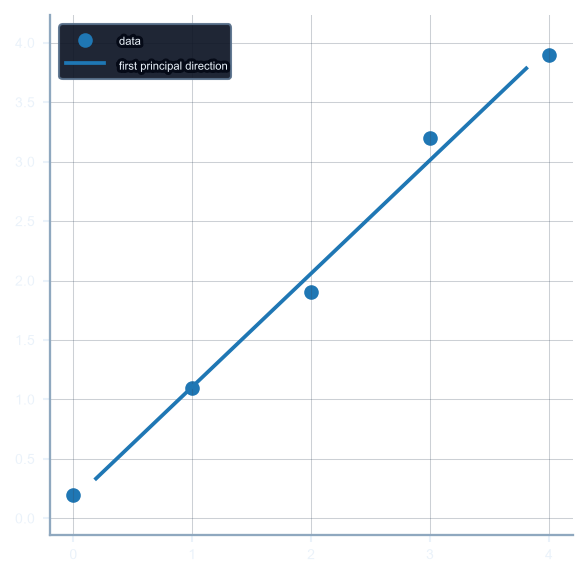

In [11]:
import numpy as np, matplotlib.pyplot as plt

X = np.array([
    [0.0, 0.2], [1.0, 1.1], [2.0, 1.9], [3.0, 3.2], [4.0, 3.9]
])
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
principal = Vt[0]

plt.figure(figsize=(4.5, 4.5))
plt.scatter(X[:,0], X[:,1], label='data')
center = X.mean(axis=0)
line = np.vstack([center - principal*2.5, center + principal*2.5])
plt.plot(line[:,0], line[:,1], label='first principal direction')
plt.axis('equal'); plt.grid(True, alpha=.25); plt.legend(); plt.show()
print('principal direction =', np.round(principal, 3))

# 数值备份（看不到图时也能确认结论）
angle_deg = np.degrees(np.arctan2(principal[1], principal[0]))
print(f'主方向的倾斜角度 ≈ {angle_deg:.1f}°（如果看不到上面的图，只看这个数字也可以：数据大致沿这个角度散开）')


## 3. SVD：任何矩阵都能拆成 `A = U · S · Vᵀ`（S 是奇异值,衡量每个方向的重要性）

In [12]:
A = np.array([[3.0,1.0,1.0],[1.0,3.0,1.0],[1.0,1.0,3.0]])
U, S, Vt = np.linalg.svd(A)
print('奇异值 S:', np.round(S, 3))
recon = U @ np.diag(S) @ Vt
print('U·S·Vᵀ 还原 A?', np.allclose(recon, A))

奇异值 S: [5. 2. 2.]
U·S·Vᵀ 还原 A? True


## 3.1 SVD：把矩阵拆成方向和强度

`A = U · S · Vᵀ` 可以读成三步：

1. `Vᵀ`：换到一组输入方向。
2. `S`：沿这些方向拉伸或压缩。
3. `U`：转到输出方向。

低秩近似（low-rank approximation）就是只保留最大的几个拉伸强度。


### 追问：为什么偏偏是这个顺序？为什么 U、Vᵀ 必须是正交矩阵？

**这个分解在"图"上想干什么**：工程师想把任何一个矩阵 A（不管多复杂、多不规则）都拆成三个"看得懂"的动作——旋转、拉伸、再旋转。写成 `A = U · S · Vᵀ`，从右往左读：先用 `Vᵀ` 把输入向量转到一组"标准方向"上，再用 `S`（对角矩阵）沿着这些方向单纯地拉伸或压缩（不改变方向，只改变长度），最后用 `U` 把结果转到输出空间里合适的方向。之所以拆成"转 - 拉 - 转"，是因为"拉伸"是最简单、最容易理解和压缩的操作（只是几个数字），而复杂的旋转部分被两头的 U、Vᵀ 扛走了。

**为什么 U 和 Vᵀ 必须是正交矩阵**：上一课（L13）学过，正交矩阵的关键特性是"保长度、保夹角"——只转方向，不改变向量的大小。SVD 要求中间的 S 是唯一"负责拉伸"的部分：如果 U 或 Vᵀ 不是正交矩阵，它们自己转向量的时候就会顺带改变长度，那"到底拉伸了多少"这个信息就会被两头的矩阵和中间的 S 混在一起，S 就不再能单独、干净地告诉我们"每个方向的重要性"了。要求 U、Vᵀ 正交，相当于立规矩："负责转向的两位只能转方向，不能偷偷顺带拉伸"，把拉伸这件事完全留给 S 一个人负责。

下面用一个具体的 2×2 矩阵，把 x 依次经过 `Vᵀ → S → U` 三步的变化打印出来，和直接算 `A @ x` 对比。

In [13]:
import numpy as np

A_step = np.array([[3.0, 1.0], [1.0, 3.0]])
U, S, Vt = np.linalg.svd(A_step)
x = np.array([1.0, 0.0])

step1 = Vt @ x                  # 第一步：转到一组新的输入方向
step2 = S * step1                # 第二步：沿这些方向拉伸（S是对角矩阵的对角线，逐元素乘即可）
step3 = U @ step2                # 第三步：转到输出方向

print('原始 x         =', x)
print('第一步 Vt@x    =', step1, '  (换到一组新方向)')
print('第二步 S*步骤1 =', step2, '  (沿这些方向拉伸)')
print('第三步 U@步骤2 =', step3, '  (转到输出方向)')
print('直接算 A@x     =', A_step @ x, '  (应该和第三步一致)')
print('三步是否等于直接算 A@x:', np.allclose(step3, A_step @ x))


原始 x         = [1. 0.]
第一步 Vt@x    = [-0.70710678 -0.70710678]   (换到一组新方向)
第二步 S*步骤1 = [-2.82842712 -1.41421356]   (沿这些方向拉伸)
第三步 U@步骤2 = [3. 1.]   (转到输出方向)
直接算 A@x     = [3. 1.]   (应该和第三步一致)
三步是否等于直接算 A@x: True


### 老陈问的具体例子：对角矩阵 A = diag([2, 3]) 的 SVD，U 和 Vᵀ 会是单位矩阵吗？

对角矩阵本身已经是"沿坐标轴拉伸"，不需要额外旋转——所以如果对角线上的数字已经是降序排列的，U、Vᵀ 就正好是单位矩阵（或者只差一个符号）。但如果对角线上的数字不是降序排列，SVD 为了保持"σ 必须降序"这条规矩，会用 U（或 Vᵀ）把顺序"倒腾"一下——这时 U 就不再是单位矩阵了。下面两个例子对比一下。

In [14]:
import numpy as np

# 情况一：对角线已经是降序 -> U、Vt 应该就是单位矩阵（或差个符号）
A_diag = np.diag([3.0, 2.0])
U_d, S_d, Vt_d = np.linalg.svd(A_diag)
print('A = diag([3,2])（已降序）')
print('U =\n', np.round(U_d, 3))
print('S =', S_d)
print('Vt =\n', np.round(Vt_d, 3))

print()
# 情况二：对角线不是降序（2 < 5）-> SVD 必须重新排序，U 不再是单位矩阵
A_diag2 = np.diag([2.0, 5.0])
U2, S2, Vt2 = np.linalg.svd(A_diag2)
print('A = diag([2,5])（未降序）')
print('S =', S2, ' <- 依然自动变成降序！')
print('U =\n', np.round(U2, 3), ' <- 不再是单位矩阵，因为 SVD 要把 5 排到前面')


A = diag([3,2])（已降序）
U =
 [[1. 0.]
 [0. 1.]]
S = [3. 2.]
Vt =
 [[1. 0.]
 [0. 1.]]

A = diag([2,5])（未降序）
S = [5. 2.]  <- 依然自动变成降序！
U =
 [[0. 1.]
 [1. 0.]]  <- 不再是单位矩阵，因为 SVD 要把 5 排到前面


## 3. 练习：低秩近似（只保留最大的 k 个奇异值）

这正是 LoRA / 推荐里"压缩矩阵"的核心。

**提示（结构性伪码，不提供具体索引写法）**：
```
1. 对 A 做 SVD -> 得到 U, S, Vt
2. 只取 U 的前 k 列 -> U_k  (shape: m x k)
3. 只取 S 的前 k 个值 -> S_k  (shape: k,)，用 np.diag 转为对角矩阵
4. 只取 Vt 的前 k 行 -> Vt_k (shape: k x n)
5. 三者按顺序相乘，返回 shape 与 A 相同的近似矩阵
```

### 写 `low_rank_approx` 前明确三件事

- 输入：矩阵 `A`（shape `(m, n)`）和保留的秩 `k`
- 关键步骤：对 `A` 做 SVD，分别截取 U 的前 k 列、S 的前 k 个奇异值（用 `np.diag` 转为对角矩阵）、Vt 的前 k 行，再按 U_k, S_k_diag, Vt_k 三个矩阵依次相乘
- 返回：shape 与 `A` 相同的秩-k 近似矩阵，`k` 越小，误差越大

In [15]:
def low_rank_approx(A, k):
    """返回 A 的秩-k 近似矩阵（shape 与 A 相同）。

    参数
    ----
    A : np.ndarray, shape (m, n)
    k : int, 保留的奇异值数量，1 <= k <= min(m, n)
    """
    U, S, Vt = np.linalg.svd(A)
    # TODO: 用前 k 个奇异值重建 A 的近似
    # 提示：取 U 的前 k 列、S 的前 k 个值（np.diag 转对角矩阵）、Vt 的前 k 行，三者相乘
    raise NotImplementedError("TODO: 返回 shape 与 A 相同的秩-k 近似矩阵")


In [16]:
try:
    _test_placeholder = low_rank_approx(np.eye(2), 1)
except (NotImplementedError, TypeError):
    print("low_rank_approx 尚未实现，请先完成 cell-18 的 TODO 再运行本单元。")
else:
    # 完整测试（仅在实现后运行）
    A = np.array([[3.0,1.0,1.0],[1.0,3.0,1.0],[1.0,1.0,3.0]])
    A1 = low_rank_approx(A, 1)   # 只用最重要的 1 个方向
    A3 = low_rank_approx(A, 3)   # 用全部 -> 完全还原
    print('rank-1 近似:\n', np.round(A1, 2))
    print('rank-3 应= A:', np.allclose(A3, A))
    assert np.allclose(A3, A), 'k=满秩 应完全还原'
    print('\n通过：你做出了 LoRA/推荐 背后的核心操作。')

    # 矩形矩阵（4x3）：确认 shape 不崩、全秩还原正确
    B = np.array([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.],[10.,11.,12.]])
    B_k2 = low_rank_approx(B, 2)
    assert B_k2.shape == B.shape, f'矩形矩阵 low_rank_approx shape 应为 {B.shape}，得到 {B_k2.shape}'
    B_full = low_rank_approx(B, min(*B.shape))
    assert np.allclose(B_full, B, atol=1e-10), '矩形矩阵全秩还原失败'
    print('矩形矩阵（4x3）low_rank_approx shape 和全秩还原均通过')


low_rank_approx 尚未实现，请先完成 cell-18 的 TODO 再运行本单元。


**🔗 Aurora 连接**：Month 4 推荐(矩阵分解)、Month 5 LoRA 微调(低秩适配)、embedding 降维可视化——全是今天这套 SVD 思想。

**🎉 前导线代课完成**：你已握住 Aurora 工程里最常用的线代工具。下一块数学(微积分/概率)等进 Month 2 深度学习前再补。

## 🎨 图示：矩阵 = 秩1矩阵之和 (SVD 的核心画面)

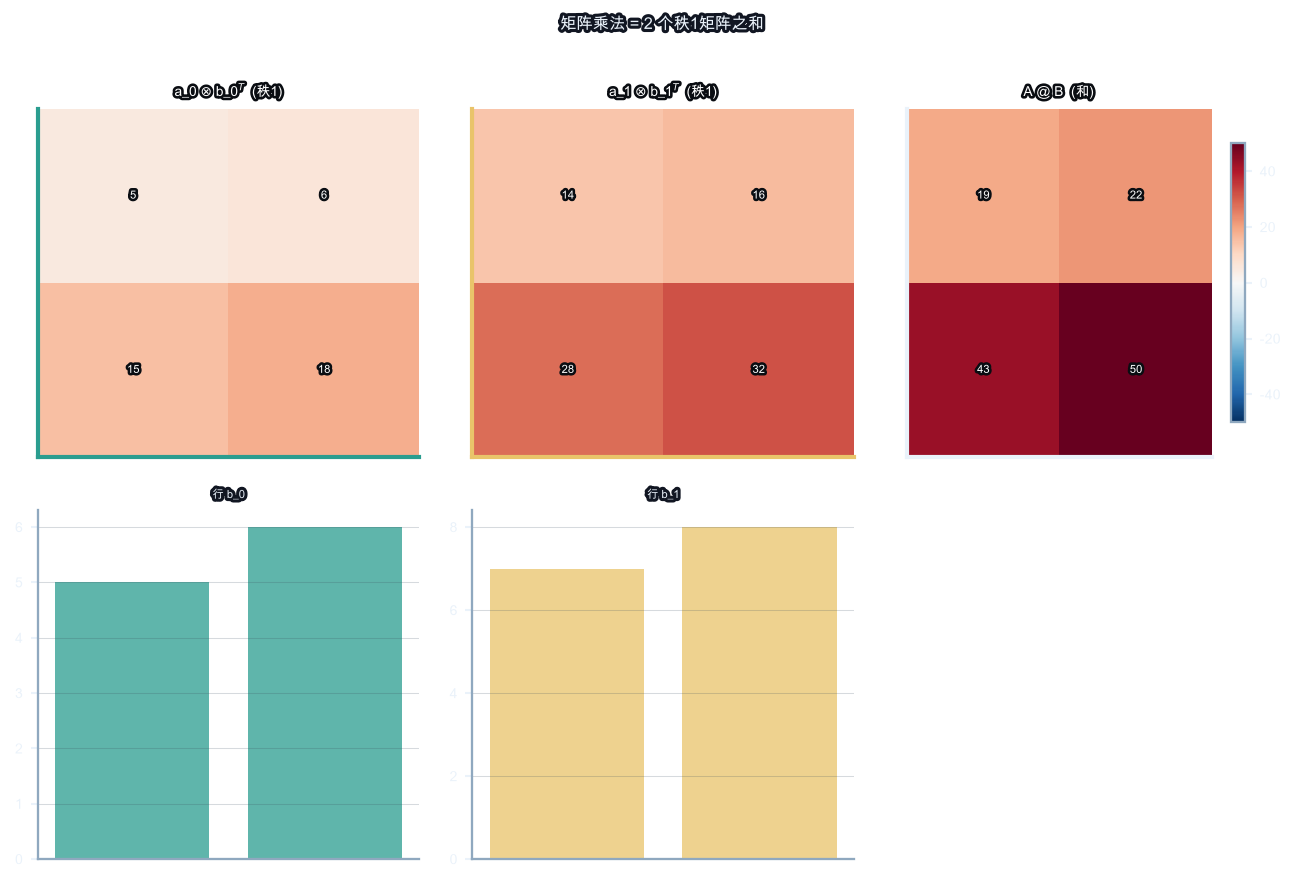

In [17]:
from aurora.laviz import style, mat_times_mat_rank1
style()
mat_times_mat_rank1([[1,2],[3,4]],[[5,6],[7,8]]);

## 🎯 未来的回报 (Future Payoff)

今天你亲手搞懂的 **低秩（low-rank）近似**，会在 **JPEG 图像压缩 / PCA 降维 / Embedding 可视化 / L84 LoRA 微调 / 模型压缩** 里一次次原样出现——它们表面五花八门，内核都是同一句话：**保留前 k 个奇异值，扔掉其余方向**。把今天这把钥匙攥紧，后面很多"高级"技巧你会发现只是它换了件衣服。


In [18]:
import numpy as np

# 条件数 κ(A) = σ_max / σ_min：越大数值越不稳定
for label, A in [
    ('近似正交', np.array([[1.,0.],[0.,1.]])),
    ('病态矩阵', np.array([[1.,1.],[1.,1.0001]])),
    ('秩不满', np.array([[1.,2.],[2.,4.]])),
]:
    s = np.linalg.svd(A, compute_uv=False)
    kappa = s[0]/s[-1] if s[-1]>1e-12 else float('inf')
    print(f'{label:8s}  σ={np.round(s,4)}  κ={kappa:.2f}')


近似正交      σ=[1. 1.]  κ=1.00
病态矩阵      σ=[2.0001 0.    ]  κ=40002.00
秩不满       σ=[5. 0.]  κ=inf


## 参数实验：只改一个旋钮

把 `k` 从 1 改到矩阵满秩，观察低秩近似误差 `||A - Ak||` 如何随 k 减小。再把矩阵 A 换成秩为 1 的矩阵，确认 k=1 时近似误差为零。

## 本课收束

`np.linalg.eig(A)` 返回特征值数组 `vals` 和特征向量矩阵 `vecs`，可逐列验证 `A @ vecs[:, i] ≈ vals[i] * vecs[:, i]`。`np.linalg.svd(A, full_matrices=True)` 返回 `U`、`S`、`Vt`，用 `U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]` 即得 `low_rank_approx(A, k)` 的核心运算。Aurora 音频去噪管线在 STFT 频谱矩阵上砍掉最小的那几个奇异值，把能量很低的背景噪声压下去。LoRA 微调把预训练权重矩阵表示为两个低秩因子之积，是同一套截断 SVD——下一节（**L15** 线性方程组）会用特征值判断系数矩阵是否可逆。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：特征值与 SVD 手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：A = [[2, 0], [0, 3]]（对角矩阵），直接写出特征值和特征向量。  
（不需要计算，对角矩阵的规律：λᵢ = 对角元素，vᵢ = 对应坐标轴）

**问 2**：`low_rank_approx(A, k)` 的输出 shape 是什么？  
若 A 的 shape 是 (3, 5)，k=2，输出 shape 仍是 (3, 5) 还是 (3, 2)？

**问 3**：SVD 中，`S`（奇异值向量）满足什么排列规则？  
为什么 k=1 近似用的是第一个奇异值，而不是最后一个？

**问 4**：A = np.eye(3)（3×3 单位矩阵），它的奇异值是什么？  
（提示：I = U·S·Vᵀ，U=V=I，所以 S = ?）

推导完成后运行下面格对答案。

In [19]:
# ✏️ 对答案格
import numpy as np

# 问1：对角矩阵特征值/向量
A1 = np.array([[2., 0.], [0., 3.]])
vals, vecs = np.linalg.eig(A1)
assert set(np.round(np.sort(vals), 6)) == {2.0, 3.0}
print(f"Q1 ✅  diag(2,3) 特征值={np.sort(vals)}，特征向量=坐标轴方向")
# 验证 Av = λv
for i in range(2):
    Av = A1 @ vecs[:, i]
    lv = vals[i] * vecs[:, i]
    assert np.allclose(Av, lv, atol=1e-10)
print(f"       Av=λv 验证通过（两列均满足方向不变）")

# 问2：low_rank_approx shape
A2 = np.random.default_rng(42).standard_normal((3, 5))
try:
    approx = low_rank_approx(A2, 2)
    assert approx.shape == A2.shape, f"shape 应为 {A2.shape}，得到 {approx.shape}"
    print(f"\nQ2 ✅  low_rank_approx(shape=(3,5), k=2) → shape={approx.shape}（与 A 相同）")
except (NotImplementedError, TypeError):
    print("\n⬜ Q2：请先实现 low_rank_approx()，再运行对答案格")

# 问3：奇异值排列
U, S, Vt = np.linalg.svd(A2)
assert all(S[i] >= S[i+1] for i in range(len(S)-1)), "S 应降序排列"
print(f"Q3 ✅  奇异值降序排列 S[0]≥S[1]≥...（最大的方向最重要，k=1用S[0]）")

# 问4：单位矩阵奇异值
I3 = np.eye(3)
_, S_I, _ = np.linalg.svd(I3)
assert np.allclose(S_I, np.ones(3), atol=1e-12)
print(f"Q4 ✅  eye(3) 奇异值 = {S_I}（全为1，单位矩阵各方向等重要）")
print("\n🎉 特征值&SVD 白板挑战通过！方向不变轴与低秩分解已内化。")

Q1 ✅  diag(2,3) 特征值=[2.+0.j 3.+0.j]，特征向量=坐标轴方向
       Av=λv 验证通过（两列均满足方向不变）

⬜ Q2：请先实现 low_rank_approx()，再运行对答案格
Q3 ✅  奇异值降序排列 S[0]≥S[1]≥...（最大的方向最重要，k=1用S[0]）
Q4 ✅  eye(3) 奇异值 = [1. 1. 1.]（全为1，单位矩阵各方向等重要）

🎉 特征值&SVD 白板挑战通过！方向不变轴与低秩分解已内化。


In [ ]:
# ✏️ 本课自评
l14_review = {
    "eigenvector_intuition":     None,  # 理解 Av=λv：特征向量方向不变？True/False
    "low_rank_approx_implemented": None,  # low_rank_approx 实现并通过断言？True/False
    "svd_decomposition_understood": None,  # 理解 A=UΣVᵀ 各部分含义？True/False
    "singular_value_ordering":   None,  # 知道奇异值降序排列，k=1用最大的？True/False
    "whiteboard_passed":         None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l14_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l14_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L14 全部通关！进入 L15：高斯消元')

---

→ **下一课**　[L15 · 高斯消元](L15_linear_systems.ipynb)

> 下节课将学习 **高斯消元**：方程组 Ax=b 的消元过程，行阶梯形与解的存在性分类。